# Changepoint Injection

This example demonstrates how to inject changepoints (structural breaks in level, trend, or variance) into time series using the changepoint parameters available in any generator.

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast.generators import (
    RandomWalkGenerator,
    SeasonalGenerator,
    VARGenerator,
)

## Level Shift Changepoints

Inject 3 level shift changepoints at specific locations (20%, 50%, and 80% of the series) with defined magnitudes.

In [ ]:
level_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "drift": 0.1,
    "volatility": 2.0,
    "changepoints": True,
    "num_changepoints": 3,
    "changepoint_type": "level",
    "changepoint_level_changes": [50.0, -30.0, 40.0],
    "changepoint_locations": [0.2, 0.5, 0.8],
    "seed": 42,
}
level_gen = RandomWalkGenerator(engine="polars", **level_params)
level_df = level_gen.generate(n_series=1)

print(f"Generated {len(level_df)} observations with 3 level shift changepoints")
print("Changepoints at 20%, 50%, and 80% of series with changes: +50, -30, +40")
print(
    f"\nStatistics: Mean={level_df['y'].mean():.4f}, "
    f"Min={level_df['y'].min():.4f}, Max={level_df['y'].max():.4f}"
)
level_df.head(10)

Generated 300 observations with 3 level shift changepoints
Changepoints at 20%, 50%, and 80% of series with changes: +50, -30, +40

Statistics: Mean=54.5807, Min=-4.4151, Max=98.6805


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-2.703188
"""0""",2000-01-02 00:00:00,-4.415079
"""0""",2000-01-03 00:00:00,-2.404967
"""0""",2000-01-04 00:00:00,-1.623656
"""0""",2000-01-05 00:00:00,-2.522745
"""0""",2000-01-06 00:00:00,-3.752405
"""0""",2000-01-07 00:00:00,-2.449278
"""0""",2000-01-08 00:00:00,-3.031034
"""0""",2000-01-09 00:00:00,-2.593973


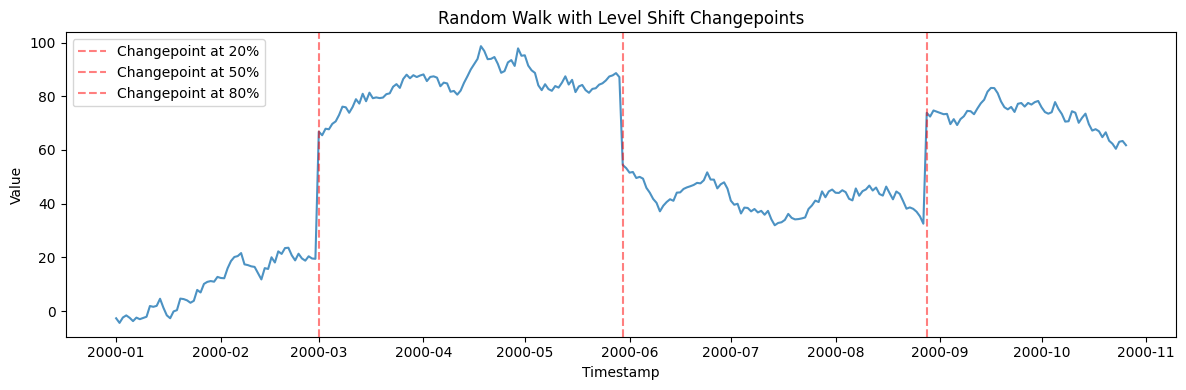

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(level_df["ds"].to_list(), level_df["y"].to_list(), alpha=0.8)
for loc in [0.2, 0.5, 0.8]:
    ax.axvline(x=level_df["ds"].to_list()[int(len(level_df) * loc)], color="red", linestyle="--", alpha=0.5, label=f"Changepoint at {int(loc*100)}%")
ax.set_title("Random Walk with Level Shift Changepoints")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Trend Changepoints

Add trend changes to a seasonal series. The slope increases at 30% and decreases at 70% of the series.

In [ ]:
trend_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "seasonality_period": 7,
    "seasonality_amplitude": 10.0,
    "base_level": 100.0,
    "changepoints": True,
    "num_changepoints": 2,
    "changepoint_type": "trend",
    "changepoint_trend_changes": [0.3, -0.2],
    "changepoint_locations": [0.3, 0.7],
    "seed": 42,
}
trend_gen = SeasonalGenerator(engine="polars", **trend_params)
trend_df = trend_gen.generate(n_series=1)

print(f"Generated {len(trend_df)} observations with 2 trend changepoints")
print("Trend changes: +0.3 at 30%, -0.2 at 70% of series")
print(
    f"\nStatistics: Mean={trend_df['y'].mean():.4f}, "
    f"Min={trend_df['y'].min():.4f}, Max={trend_df['y'].max():.4f}"
)
trend_df.head(10)

Generated 300 observations with 2 trend changepoints
Trend changes: +0.3 at 30%, -0.2 at 70% of series

Statistics: Mean=119.2540, Min=89.2285, Max=153.3620


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,98.598406
"""0""",2000-01-02 00:00:00,106.912369
"""0""",2000-01-03 00:00:00,110.704335
"""0""",2000-01-04 00:00:00,104.679493
"""0""",2000-01-05 00:00:00,95.161618
"""0""",2000-01-06 00:00:00,89.585891
"""0""",2000-01-07 00:00:00,92.783249
"""0""",2000-01-08 00:00:00,99.659122
"""0""",2000-01-09 00:00:00,107.986845


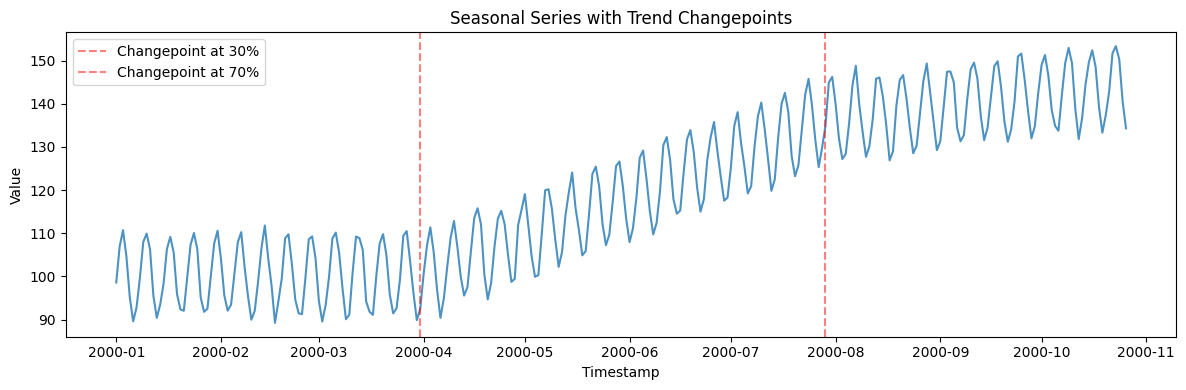

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trend_df["ds"].to_list(), trend_df["y"].to_list(), alpha=0.8)
for loc in [0.3, 0.7]:
    ax.axvline(x=trend_df["ds"].to_list()[int(len(trend_df) * loc)], color="red", linestyle="--", alpha=0.5, label=f"Changepoint at {int(loc*100)}%")
ax.set_title("Seasonal Series with Trend Changepoints")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Variance Changepoints

Change the variance at specific points. Variance doubles at 33% and halves at 67% of the series.

In [ ]:
variance_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "drift": 0.05,
    "volatility": 2.0,
    "changepoints": True,
    "num_changepoints": 2,
    "changepoint_type": "variance",
    "changepoint_variance_changes": [2.0, 0.5],
    "changepoint_locations": [0.33, 0.67],
    "seed": 42,
}
variance_gen = RandomWalkGenerator(engine="polars", **variance_params)
variance_df = variance_gen.generate(n_series=1)

print(f"Generated {len(variance_df)} observations with 2 variance changepoints")
print("Variance multipliers: 2.0x at 33%, 0.5x at 67% of series")
print(
    f"\nStatistics: Mean={variance_df['y'].mean():.4f}, "
    f"Std={variance_df['y'].std():.4f}"
)
variance_df.head(10)

Generated 300 observations with 2 variance changepoints
Variance multipliers: 2.0x at 33%, 0.5x at 67% of series

Statistics: Mean=13.8809, Std=12.8297


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-2.753188
"""0""",2000-01-02 00:00:00,-4.515079
"""0""",2000-01-03 00:00:00,-2.554967
"""0""",2000-01-04 00:00:00,-1.823656
"""0""",2000-01-05 00:00:00,-2.772745
"""0""",2000-01-06 00:00:00,-4.052405
"""0""",2000-01-07 00:00:00,-2.799278
"""0""",2000-01-08 00:00:00,-3.431034
"""0""",2000-01-09 00:00:00,-3.043973


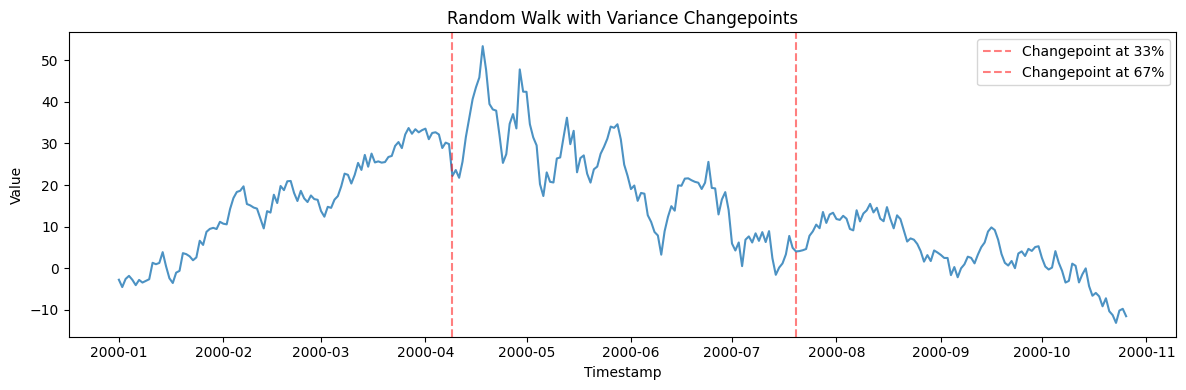

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(variance_df["ds"].to_list(), variance_df["y"].to_list(), alpha=0.8)
for loc in [0.33, 0.67]:
    ax.axvline(x=variance_df["ds"].to_list()[int(len(variance_df) * loc)], color="red", linestyle="--", alpha=0.5, label=f"Changepoint at {int(loc*100)}%")
ax.set_title("Random Walk with Variance Changepoints")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Mixed Changepoint Types

Use `changepoint_type='mixed'` to randomly combine level, trend, and variance changes at each changepoint.

In [ ]:
mixed_params = {
    "min_length": 400,
    "max_length": 400,
    "freq": "D",
    "drift": 0.1,
    "volatility": 2.0,
    "changepoints": True,
    "num_changepoints": 4,
    "changepoint_type": "mixed",
    "changepoint_locations": [0.2, 0.4, 0.6, 0.8],
    "seed": 42,
}
mixed_gen = RandomWalkGenerator(engine="polars", **mixed_params)
mixed_df = mixed_gen.generate(n_series=1)

print(f"Generated {len(mixed_df)} observations with 4 mixed changepoints")
print(
    f"\nStatistics: Mean={mixed_df['y'].mean():.4f}, "
    f"Min={mixed_df['y'].min():.4f}, Max={mixed_df['y'].max():.4f}"
)
mixed_df.head(10)

Generated 400 observations with 4 mixed changepoints

Statistics: Mean=-12.7672, Min=-117.0031, Max=44.8685


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-2.703188
"""0""",2000-01-02 00:00:00,-4.415079
"""0""",2000-01-03 00:00:00,-2.404967
"""0""",2000-01-04 00:00:00,-1.623656
"""0""",2000-01-05 00:00:00,-2.522745
"""0""",2000-01-06 00:00:00,-3.752405
"""0""",2000-01-07 00:00:00,-2.449278
"""0""",2000-01-08 00:00:00,-3.031034
"""0""",2000-01-09 00:00:00,-2.593973


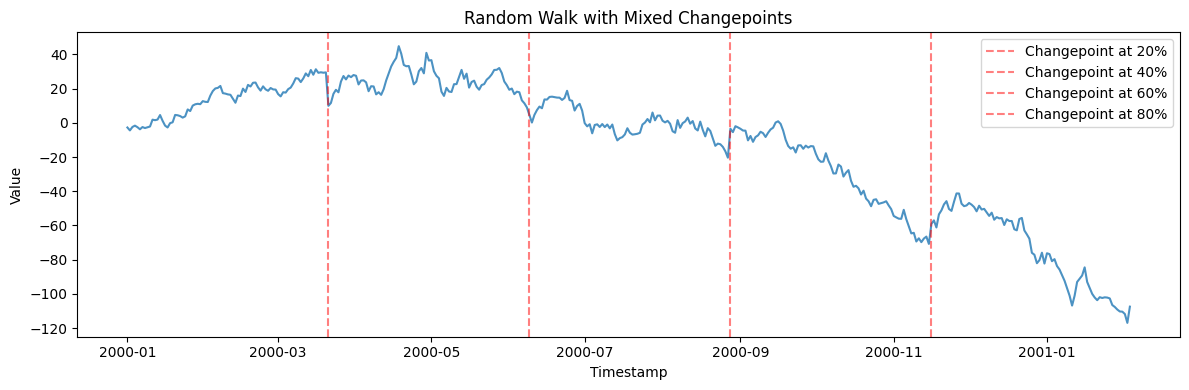

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mixed_df["ds"].to_list(), mixed_df["y"].to_list(), alpha=0.8)
for loc in [0.2, 0.4, 0.6, 0.8]:
    ax.axvline(x=mixed_df["ds"].to_list()[int(len(mixed_df) * loc)], color="red", linestyle="--", alpha=0.5, label=f"Changepoint at {int(loc*100)}%")
ax.set_title("Random Walk with Mixed Changepoints")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Random Changepoint Locations

When `changepoint_locations` is not specified, locations and magnitudes are generated randomly.

In [ ]:
random_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "drift": 0.05,
    "volatility": 2.0,
    "changepoints": True,
    "num_changepoints": 3,
    "changepoint_type": "level",
    "seed": 42,
}
random_gen = RandomWalkGenerator(engine="polars", **random_params)
random_df = random_gen.generate(n_series=1)

print(f"Generated {len(random_df)} observations with 3 randomly placed changepoints")
print(
    f"\nStatistics: Mean={random_df['y'].mean():.4f}, "
    f"Std={random_df['y'].std():.4f}"
)
random_df.head(10)

Generated 300 observations with 3 randomly placed changepoints

Statistics: Mean=24.3772, Std=16.9791


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-2.753188
"""0""",2000-01-02 00:00:00,-4.515079
"""0""",2000-01-03 00:00:00,-2.554967
"""0""",2000-01-04 00:00:00,-1.823656
"""0""",2000-01-05 00:00:00,-2.772745
"""0""",2000-01-06 00:00:00,-4.052405
"""0""",2000-01-07 00:00:00,-2.799278
"""0""",2000-01-08 00:00:00,-3.431034
"""0""",2000-01-09 00:00:00,-3.043973


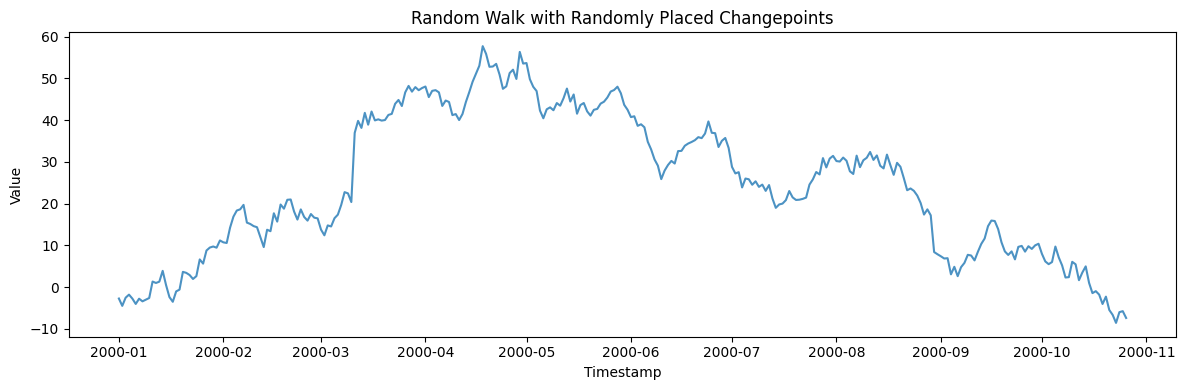

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(random_df["ds"].to_list(), random_df["y"].to_list(), alpha=0.8)
ax.set_title("Random Walk with Randomly Placed Changepoints")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## VAR Generator with Changepoints (Multivariate)

Changepoints can also be applied to multivariate generators like VAR.

In [ ]:
var_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "lag_order": 1,
    "changepoints": True,
    "num_changepoints": 2,
    "changepoint_type": "level",
    "changepoint_level_changes": [30.0, -20.0],
    "changepoint_locations": [0.3, 0.7],
    "seed": 42,
}
var_gen = VARGenerator(engine="polars", **var_params)
var_df = var_gen.generate(n_series=3)

print(
    f"Generated 3 correlated series with changepoints ({len(var_df)} total observations)"
)
print(
    f"\nOverall Statistics: Mean={var_df['y'].mean():.4f}, "
    f"Min={var_df['y'].min():.4f}, Max={var_df['y'].max():.4f}"
)
var_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 correlated series with changepoints (600 total observations)

Overall Statistics: Mean=14.9404, Min=-2.9439, Max=32.9908


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.057667
"""0""",2000-01-02 00:00:00,0.295293
"""0""",2000-01-03 00:00:00,0.893053
"""0""",2000-01-04 00:00:00,0.235888
"""0""",2000-01-05 00:00:00,1.876363
"""0""",2000-01-06 00:00:00,-0.051986
"""0""",2000-01-07 00:00:00,1.583556
"""0""",2000-01-08 00:00:00,-1.001584
"""0""",2000-01-09 00:00:00,-0.94835


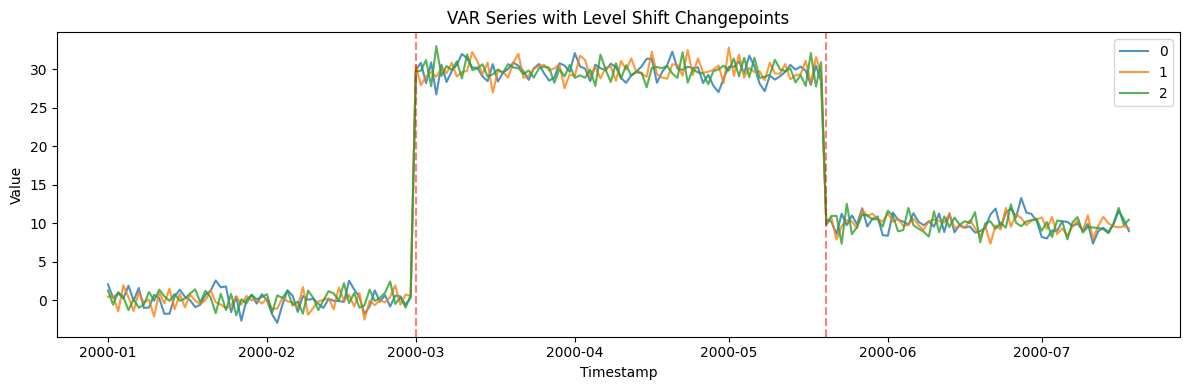

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in var_df["unique_id"].unique().to_list():
    series = var_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
for loc in [0.3, 0.7]:
    ax.axvline(x=var_df.filter(pl.col("unique_id") == "0")["ds"].to_list()[int(200 * loc)], color="red", linestyle="--", alpha=0.5)
ax.set_title("VAR Series with Level Shift Changepoints")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Changepoints with Anomalies

Combine changepoints with anomaly injection for more realistic data with both structural breaks and outliers.

In [ ]:
combined_anomalies_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "drift": 0.1,
    "volatility": 2.0,
    "changepoints": True,
    "num_changepoints": 2,
    "changepoint_type": "level",
    "changepoint_level_changes": [40.0, -30.0],
    "changepoint_locations": [0.33, 0.67],
    "anomalies": True,
    "anomaly_fraction": 0.05,
    "anomaly_types": ["spike", "dip"],
    "spike_magnitude": 35.0,
    "dip_magnitude": -35.0,
    "seed": 42,
}
combined_anomalies_gen = RandomWalkGenerator(engine="polars", **combined_anomalies_params)
combined_anomalies_df = combined_anomalies_gen.generate(n_series=1)

print(
    f"Generated {len(combined_anomalies_df)} observations with both "
    f"changepoints and anomalies"
)
print(
    f"\nStatistics: Mean={combined_anomalies_df['y'].mean():.4f}, "
    f"Min={combined_anomalies_df['y'].min():.4f}, Max={combined_anomalies_df['y'].max():.4f}"
)
combined_anomalies_df.head(10)

Generated 300 observations with both changepoints and anomalies

Statistics: Mean=37.8974, Min=-33.1327, Max=88.6805


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-2.703188
"""0""",2000-01-02 00:00:00,-4.415079
"""0""",2000-01-03 00:00:00,-2.404967
"""0""",2000-01-04 00:00:00,-1.623656
"""0""",2000-01-05 00:00:00,-2.522745
"""0""",2000-01-06 00:00:00,-3.752405
"""0""",2000-01-07 00:00:00,-2.449278
"""0""",2000-01-08 00:00:00,-3.031034
"""0""",2000-01-09 00:00:00,-2.593973


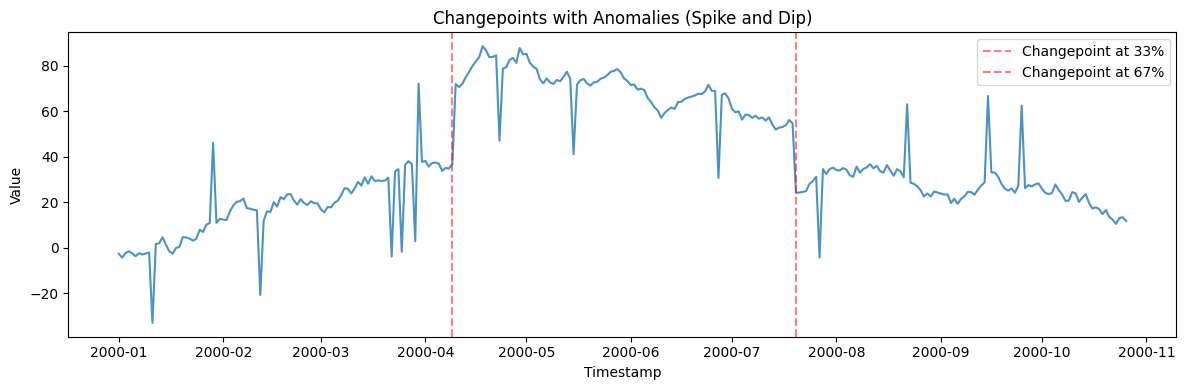

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(combined_anomalies_df["ds"].to_list(), combined_anomalies_df["y"].to_list(), alpha=0.8)
for loc in [0.33, 0.67]:
    ax.axvline(x=combined_anomalies_df["ds"].to_list()[int(len(combined_anomalies_df) * loc)], color="red", linestyle="--", alpha=0.5, label=f"Changepoint at {int(loc*100)}%")
ax.set_title("Changepoints with Anomalies (Spike and Dip)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Changepoints with Missing Data

Combine changepoints with missing data patterns to simulate real-world scenarios with both structural breaks and data gaps.

In [ ]:
combined_missing_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "drift": 0.1,
    "volatility": 2.0,
    "changepoints": True,
    "num_changepoints": 2,
    "changepoint_type": "level",
    "changepoint_level_changes": [35.0, -25.0],
    "missing_data": True,
    "missing_pattern": "random",
    "missing_rate": 0.1,
    "seed": 42,
}
combined_missing_gen = RandomWalkGenerator(engine="polars", **combined_missing_params)
combined_missing_df = combined_missing_gen.generate(n_series=1)
null_count = combined_missing_df["y"].null_count()

print(
    f"Generated {len(combined_missing_df)} observations with both "
    f"changepoints and missing data ({null_count} missing values)"
)
print(
    f"\nStatistics (excluding nulls): Mean={combined_missing_df['y'].mean():.4f}, "
    f"Min={combined_missing_df['y'].min():.4f}, Max={combined_missing_df['y'].max():.4f}"
)
combined_missing_df.head(15)

Generated 300 observations with both changepoints and missing data (0 missing values)

Statistics (excluding nulls): Mean=nan, Min=-4.4151, Max=83.6805


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-2.703188
"""0""",2000-01-02 00:00:00,-4.415079
"""0""",2000-01-03 00:00:00,-2.404967
"""0""",2000-01-04 00:00:00,-1.623656
"""0""",2000-01-05 00:00:00,-2.522745
…,…,…
"""0""",2000-01-11 00:00:00,1.867297
"""0""",2000-01-12 00:00:00,NaN
"""0""",2000-01-13 00:00:00,1.930384


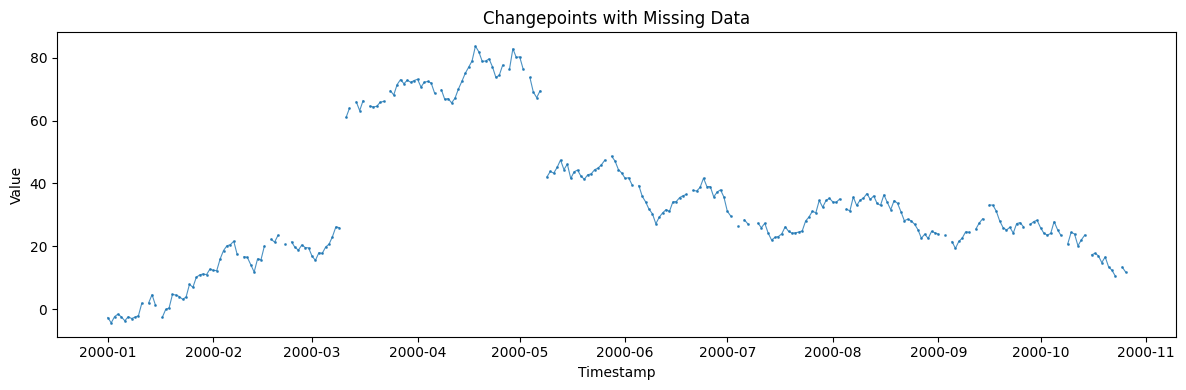

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(combined_missing_df["ds"].to_list(), combined_missing_df["y"].to_list(), alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("Changepoints with Missing Data")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## All Features Combined

Combine changepoints, anomalies, and missing data in a single series for the most realistic scenario.

In [ ]:
all_features_params = {
    "min_length": 400,
    "max_length": 400,
    "freq": "D",
    "drift": 0.1,
    "volatility": 2.0,
    "changepoints": True,
    "num_changepoints": 3,
    "changepoint_type": "mixed",
    "changepoint_locations": [0.25, 0.5, 0.75],
    "anomalies": True,
    "anomaly_fraction": 0.05,
    "anomaly_types": ["spike", "dip", "level_shift"],
    "spike_magnitude": 40.0,
    "dip_magnitude": -40.0,
    "level_shift_magnitude": 30.0,
    "level_shift_duration": 15,
    "missing_data": True,
    "missing_pattern": "random",
    "missing_rate": 0.08,
    "seed": 42,
}
all_features_gen = RandomWalkGenerator(engine="polars", **all_features_params)
all_features_df = all_features_gen.generate(n_series=1)
null_count_all = all_features_df["y"].null_count()

print(
    f"Generated {len(all_features_df)} observations with changepoints, "
    f"anomalies, AND missing data ({null_count_all} missing values)"
)
print(
    f"\nStatistics (excluding nulls): Mean={all_features_df['y'].mean():.4f}, "
    f"Min={all_features_df['y'].min():.4f}, Max={all_features_df['y'].max():.4f}"
)
all_features_df.head(15)

Generated 400 observations with changepoints, anomalies, AND missing data (0 missing values)

Statistics (excluding nulls): Mean=nan, Min=-19.6049, Max=165.9694


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-2.703188
"""0""",2000-01-02 00:00:00,-4.415079
"""0""",2000-01-03 00:00:00,-2.404967
"""0""",2000-01-04 00:00:00,-1.623656
"""0""",2000-01-05 00:00:00,-2.522745
…,…,…
"""0""",2000-01-11 00:00:00,1.867297
"""0""",2000-01-12 00:00:00,1.575591
"""0""",2000-01-13 00:00:00,1.930384


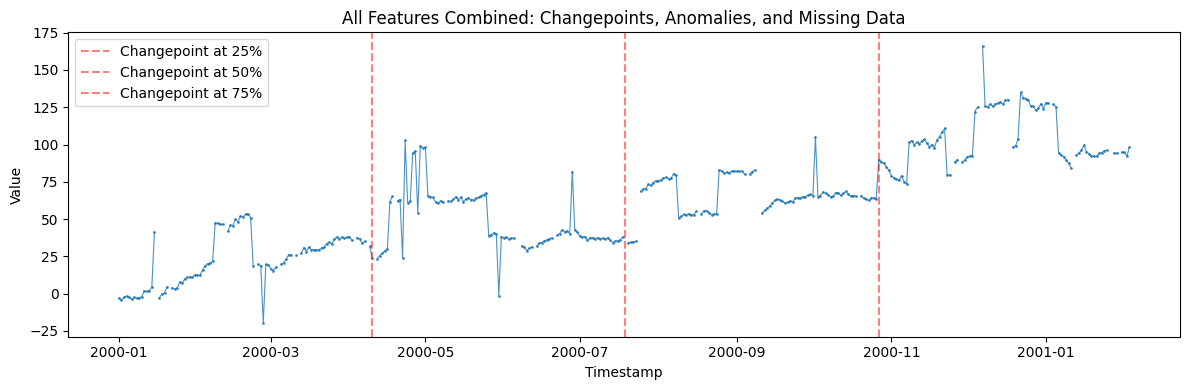

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_features_df["ds"].to_list(), all_features_df["y"].to_list(), alpha=0.8, marker=".", markersize=2, linewidth=0.8)
for loc in [0.25, 0.5, 0.75]:
    ax.axvline(x=all_features_df["ds"].to_list()[int(len(all_features_df) * loc)], color="red", linestyle="--", alpha=0.5, label=f"Changepoint at {int(loc*100)}%")
ax.set_title("All Features Combined: Changepoints, Anomalies, and Missing Data")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()